# Notebook 13: Statistical Significance & Ablation Study
## Phase 3: Research Rigor for NCKH

### Objectives
1. Bootstrap confidence intervals (95% CI) for all metrics
2. Ablation study: Impact of ROI preprocessing
3. Paired statistical tests: baseline vs optimized
4. Generate publication-ready statistical tables

## Step 1: Setup & Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from scipy import stats
from sklearn.metrics import roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Setup
project_root = Path('/Users/GiangNguyenHuy/Documents/breast-cancer-ai')
sys.path.insert(0, str(project_root))

from src.evaluation import calculate_clinical_metrics

# Plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All imports successful')

✅ All imports successful


## Step 2: Load Data & Models

In [2]:
def load_images_from_directory(directory, label):
    """Load images from directory."""
    images = []
    labels = []
    
    dir_path = Path(directory)
    image_files = sorted(dir_path.glob('*.png'))
    
    for img_file in image_files:
        try:
            img = keras.preprocessing.image.load_img(
                str(img_file), target_size=(224, 224)
            )
            img_array = keras.preprocessing.image.img_to_array(img)
            img_array = img_array / 255.0
            images.append(img_array)
            labels.append(label)
        except:
            continue
    
    return np.array(images), np.array(labels)

# Load ROI test set
print("Loading ROI test set...")
roi_base = project_root / 'data/cbis_ddsm/processed/images_roi/test'
test_ben_roi, _ = load_images_from_directory(roi_base / 'benign', 0)
test_mal_roi, _ = load_images_from_directory(roi_base / 'malignant', 1)
X_test_roi = np.concatenate([test_ben_roi, test_mal_roi])
y_test_roi = np.concatenate([np.zeros(len(test_ben_roi)), np.ones(len(test_mal_roi))])

# Load original test set (for ablation study)
print("Loading original test set...")
orig_base = project_root / 'data/cbis_ddsm/processed/images/test'
test_ben_orig, _ = load_images_from_directory(orig_base / 'benign', 0)
test_mal_orig, _ = load_images_from_directory(orig_base / 'malignant', 1)
X_test_orig = np.concatenate([test_ben_orig, test_mal_orig])
y_test_orig = np.concatenate([np.zeros(len(test_ben_orig)), np.ones(len(test_mal_orig))])

# Shuffle both
from sklearn.utils import shuffle
X_test_roi, y_test_roi = shuffle(X_test_roi, y_test_roi, random_state=42)
X_test_orig, y_test_orig = shuffle(X_test_orig, y_test_orig, random_state=42)

print(f"ROI test set: {X_test_roi.shape}")
print(f"Original test set: {X_test_orig.shape}")

Loading ROI test set...
Loading original test set...
ROI test set: (386, 224, 224, 3)
Original test set: (386, 224, 224, 3)


## Step 3: Load Models (Baseline + Optimized)

In [3]:
# Load models
print("Loading models...")

# Original model (baseline)
model_baseline = keras.models.load_model(
    str(project_root / 'models/deep_learning/custom_cnn_best.keras')
)

# Fine-tuned model (optimized)
model_optimized = keras.models.load_model(
    str(project_root / 'models/deep_learning/custom_cnn_v2_finetuned_roi.keras')
)

print(f"✅ Baseline model: {model_baseline.name}")
print(f"✅ Optimized model: {model_optimized.name}")

Loading models...
✅ Baseline model: Custom_CNN_Mammogram
✅ Optimized model: Custom_CNN_Mammogram


## Step 4: Ablation Study - Impact of ROI Preprocessing

In [4]:
# Test baseline model on BOTH original and ROI images
print("Generating baseline model predictions...")
y_pred_baseline_orig = model_baseline.predict(X_test_orig, verbose=0).flatten()
y_pred_baseline_roi = model_baseline.predict(X_test_roi, verbose=0).flatten()

# Test optimized model on both
print("Generating optimized model predictions...")
y_pred_optimized_orig = model_optimized.predict(X_test_orig, verbose=0).flatten()
y_pred_optimized_roi = model_optimized.predict(X_test_roi, verbose=0).flatten()

# Create ablation comparison
ablation_results = []

# 1. Baseline + Original images
y_pred = (y_pred_baseline_orig >= 0.5).astype(int)
metrics = calculate_clinical_metrics(y_test_orig, y_pred, y_pred_baseline_orig)
metrics['condition'] = 'Baseline Model + Original Images'
metrics['threshold'] = 0.5
metrics['roc_auc'] = roc_auc_score(y_test_orig, y_pred_baseline_orig)
ablation_results.append(metrics)

# 2. Baseline + ROI images
y_pred = (y_pred_baseline_roi >= 0.5).astype(int)
metrics = calculate_clinical_metrics(y_test_roi, y_pred, y_pred_baseline_roi)
metrics['condition'] = 'Baseline Model + ROI Images'
metrics['threshold'] = 0.5
metrics['roc_auc'] = roc_auc_score(y_test_roi, y_pred_baseline_roi)
ablation_results.append(metrics)

# 3. Optimized + Original images
y_pred = (y_pred_optimized_orig >= 0.39).astype(int)
metrics = calculate_clinical_metrics(y_test_orig, y_pred, y_pred_optimized_orig)
metrics['condition'] = 'Optimized Model + Original Images'
metrics['threshold'] = 0.39
metrics['roc_auc'] = roc_auc_score(y_test_orig, y_pred_optimized_orig)
ablation_results.append(metrics)

# 4. Optimized + ROI images
y_pred = (y_pred_optimized_roi >= 0.39).astype(int)
metrics = calculate_clinical_metrics(y_test_roi, y_pred, y_pred_optimized_roi)
metrics['condition'] = 'Optimized Model + ROI Images'
metrics['threshold'] = 0.39
metrics['roc_auc'] = roc_auc_score(y_test_roi, y_pred_optimized_roi)
ablation_results.append(metrics)

df_ablation = pd.DataFrame(ablation_results)
df_ablation = df_ablation[[
    'condition', 'threshold', 'accuracy', 'sensitivity', 'specificity',
    'ppv', 'f1_score', 'roc_auc'
]]

print("\n=== ABLATION STUDY RESULTS ===")
print(df_ablation.to_string(index=False))

# Save
csv_path = project_root / 'experiments/results/ablation_study.csv'
df_ablation.to_csv(csv_path, index=False)
print(f"\n✅ Ablation results saved to {csv_path}")

Generating baseline model predictions...
Generating optimized model predictions...

=== ABLATION STUDY RESULTS ===
                        condition  threshold  accuracy  sensitivity  specificity      ppv  f1_score  roc_auc
 Baseline Model + Original Images       0.50  0.621762     0.246914     0.892857 0.625000  0.353982 0.670304
      Baseline Model + ROI Images       0.50  0.549223     0.432099     0.633929 0.460526  0.445860 0.604608
Optimized Model + Original Images       0.39  0.476684     0.944444     0.138393 0.442197  0.602362 0.655368
     Optimized Model + ROI Images       0.39  0.479275     0.950617     0.138393 0.443804  0.605108 0.583636

✅ Ablation results saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/ablation_study.csv


## Step 5: Bootstrap Confidence Intervals

In [5]:
def bootstrap_ci(y_true, y_pred_proba, threshold=0.5, metric='accuracy', n_bootstrap=1000):
    """
    Calculate bootstrap confidence interval for a metric.
    
    Args:
        y_true: True labels
        y_pred_proba: Predicted probabilities
        threshold: Classification threshold
        metric: 'accuracy', 'sensitivity', 'specificity', 'roc_auc'
        n_bootstrap: Number of bootstrap samples
    
    Returns:
        (mean, lower_ci, upper_ci)
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    n = len(y_true)
    bootstrap_scores = []
    
    np.random.seed(42)
    
    for _ in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        y_pred_proba_boot = y_pred_proba[indices]
        
        # Calculate metric
        if metric == 'accuracy':
            score = (y_true_boot == y_pred_boot).mean()
        elif metric == 'sensitivity':
            tp = np.sum((y_pred_boot == 1) & (y_true_boot == 1))
            fn = np.sum((y_pred_boot == 0) & (y_true_boot == 1))
            score = tp / (tp + fn) if (tp + fn) > 0 else 0
        elif metric == 'specificity':
            tn = np.sum((y_pred_boot == 0) & (y_true_boot == 0))
            fp = np.sum((y_pred_boot == 1) & (y_true_boot == 0))
            score = tn / (tn + fp) if (tn + fp) > 0 else 0
        elif metric == 'roc_auc':
            try:
                score = roc_auc_score(y_true_boot, y_pred_proba_boot)
            except:
                score = 0.5
        else:
            score = 0
        
        bootstrap_scores.append(score)
    
    bootstrap_scores = np.array(bootstrap_scores)
    mean = np.mean(bootstrap_scores)
    lower = np.percentile(bootstrap_scores, 2.5)
    upper = np.percentile(bootstrap_scores, 97.5)
    
    return mean, lower, upper

print("Computing bootstrap confidence intervals (1000 samples)...")
print("This may take 2-3 minutes...\n")

# Calculate CIs for all conditions
metrics_list = ['accuracy', 'sensitivity', 'specificity', 'roc_auc']
conditions = [
    ('Baseline + Original', y_pred_baseline_orig, y_test_orig, 0.5),
    ('Baseline + ROI', y_pred_baseline_roi, y_test_roi, 0.5),
    ('Optimized + Original', y_pred_optimized_orig, y_test_orig, 0.39),
    ('Optimized + ROI', y_pred_optimized_roi, y_test_roi, 0.39),
]

bootstrap_results = []

for cond_name, y_pred_proba, y_true, threshold in conditions:
    print(f"Processing: {cond_name}...")
    for metric in metrics_list:
        mean, lower, upper = bootstrap_ci(y_true, y_pred_proba, threshold, metric)
        bootstrap_results.append({
            'condition': cond_name,
            'metric': metric,
            'mean': mean,
            'lower_ci': lower,
            'upper_ci': upper,
            'ci_range': upper - lower
        })

df_bootstrap = pd.DataFrame(bootstrap_results)

print("\n=== BOOTSTRAP CONFIDENCE INTERVALS (95%) ===")
for condition in ['Baseline + Original', 'Baseline + ROI', 'Optimized + Original', 'Optimized + ROI']:
    print(f"\n{condition}:")
    subset = df_bootstrap[df_bootstrap['condition'] == condition]
    for _, row in subset.iterrows():
        print(f"  {row['metric']:12s}: {row['mean']:.4f} [{row['lower_ci']:.4f}, {row['upper_ci']:.4f}]")

# Save
csv_path = project_root / 'experiments/results/bootstrap_confidence_intervals.csv'
df_bootstrap.to_csv(csv_path, index=False)
print(f"\n✅ Bootstrap CIs saved to {csv_path}")

Computing bootstrap confidence intervals (1000 samples)...
This may take 2-3 minutes...

Processing: Baseline + Original...
Processing: Baseline + ROI...
Processing: Optimized + Original...
Processing: Optimized + ROI...

=== BOOTSTRAP CONFIDENCE INTERVALS (95%) ===

Baseline + Original:
  accuracy    : 0.6204 [0.5725, 0.6710]
  sensitivity : 0.2445 [0.1781, 0.3121]
  specificity : 0.8924 [0.8517, 0.9293]
  roc_auc     : 0.6696 [0.6162, 0.7221]

Baseline + ROI:
  accuracy    : 0.5482 [0.4999, 0.5984]
  sensitivity : 0.4301 [0.3519, 0.5091]
  specificity : 0.6337 [0.5707, 0.6973]
  roc_auc     : 0.6035 [0.5467, 0.6586]

Optimized + Original:
  accuracy    : 0.4762 [0.4275, 0.5260]
  sensitivity : 0.9440 [0.9059, 0.9755]
  specificity : 0.1376 [0.0929, 0.1814]
  roc_auc     : 0.6542 [0.6001, 0.7087]

Optimized + ROI:
  accuracy    : 0.4788 [0.4301, 0.5285]
  sensitivity : 0.9499 [0.9107, 0.9803]
  specificity : 0.1378 [0.0932, 0.1814]
  roc_auc     : 0.5817 [0.5253, 0.6402]

✅ Bootstrap 

## Step 6: Statistical Tests (Paired Comparisons)

In [10]:
# McNemar's test: Baseline vs Optimized on the same ROI samples
from pathlib import Path
import json

# Prefer statsmodels implementation if available
try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

    def run_mcnemar(table):
        return mcnemar_test(table, exact=False, correction=True)
except ImportError:
    # Fallback: continuity-corrected chi-square approximation
    from scipy.stats import chi2

    class _McNemarResult:
        def __init__(self, statistic, pvalue):
            self.statistic = statistic
            self.pvalue = pvalue

    def run_mcnemar(table):
        n01 = table[0, 1]
        n10 = table[1, 0]
        statistic = ((abs(n01 - n10) - 1) ** 2) / (n01 + n10) if (n01 + n10) > 0 else 0.0
        pvalue = 1 - chi2.cdf(statistic, 1)
        return _McNemarResult(statistic, pvalue)

# Binary predictions at selected thresholds
y_pred_baseline = (y_pred_baseline_roi >= 0.5).astype(int)
y_pred_optimized = (y_pred_optimized_roi >= 0.39).astype(int)

# Correctness against ground truth
y_true = y_test_roi.astype(int)
baseline_correct = y_pred_baseline == y_true
optimized_correct = y_pred_optimized == y_true

# Paired outcomes
n00 = np.sum(baseline_correct & optimized_correct)      # both correct
n01 = np.sum(baseline_correct & (~optimized_correct))   # baseline correct, optimized wrong
n10 = np.sum((~baseline_correct) & optimized_correct)   # baseline wrong, optimized correct
n11 = np.sum((~baseline_correct) & (~optimized_correct))# both wrong

# McNemar test uses the 2x2 table of paired outcomes
table = np.array([[n00, n01], [n10, n11]])
result = run_mcnemar(table)

print("=== STATISTICAL TESTS ===")
print("\nMcNemar's Test (Baseline vs Optimized, ROI images):")
print(f"  Both correct (n00): {n00}")
print(f"  Baseline correct, Optimized wrong (n01): {n01}")
print(f"  Baseline wrong, Optimized correct (n10): {n10}")
print(f"  Both wrong (n11): {n11}")
print(f"  McNemar statistic: {result.statistic:.4f}")
print(f"  p-value: {result.pvalue:.6f}")
if result.pvalue < 0.05:
    print("  ✅ SIGNIFICANT: Difference between models is statistically significant (p < 0.05)")
else:
    print("  ⚠️  NOT SIGNIFICANT: No statistically significant difference (p ≥ 0.05)")

# ROC-AUC summary
print("\nAUROC Results:")
roc_auc_baseline = roc_auc_score(y_true, y_pred_baseline_roi)
roc_auc_optimized = roc_auc_score(y_true, y_pred_optimized_roi)
auc_diff = roc_auc_optimized - roc_auc_baseline
print(f"  Baseline ROC-AUC: {roc_auc_baseline:.4f}")
print(f"  Optimized ROC-AUC: {roc_auc_optimized:.4f}")
print(f"  Difference (Optimized - Baseline): {auc_diff:.4f}")

# Bootstrap CI for paired AUROC difference
rng = np.random.default_rng(42)
n_samples = len(y_true)
bootstrap_auc_diff = []
for _ in range(2000):
    idx = rng.integers(0, n_samples, n_samples)
    y_bs = y_true[idx]

    # Skip invalid bootstrap samples containing only one class
    if np.unique(y_bs).size < 2:
        continue

    auc_b = roc_auc_score(y_bs, y_pred_baseline_roi[idx])
    auc_o = roc_auc_score(y_bs, y_pred_optimized_roi[idx])
    bootstrap_auc_diff.append(auc_o - auc_b)

bootstrap_auc_diff = np.array(bootstrap_auc_diff)
auc_diff_ci_low = float(np.percentile(bootstrap_auc_diff, 2.5))
auc_diff_ci_high = float(np.percentile(bootstrap_auc_diff, 97.5))
print(f"  95% Bootstrap CI (Difference): [{auc_diff_ci_low:.4f}, {auc_diff_ci_high:.4f}]")

# Save a compact report for downstream analysis/reporting
report = {
    "mcnemar": {
        "n00_both_correct": int(n00),
        "n01_baseline_correct_optimized_wrong": int(n01),
        "n10_baseline_wrong_optimized_correct": int(n10),
        "n11_both_wrong": int(n11),
        "statistic": float(result.statistic),
        "pvalue": float(result.pvalue),
        "significant_alpha_0_05": bool(result.pvalue < 0.05),
    },
    "auroc": {
        "baseline": float(roc_auc_baseline),
        "optimized": float(roc_auc_optimized),
        "difference_optimized_minus_baseline": float(auc_diff),
        "difference_bootstrap_ci_95": [auc_diff_ci_low, auc_diff_ci_high],
        "bootstrap_samples_used": int(len(bootstrap_auc_diff)),
    },
}

output_path = Path("../experiments/results/statistical_significance_ablation.json")
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(json.dumps(report, indent=2), encoding="utf-8")
print(f"\nSaved report to: {output_path.resolve()}")

=== STATISTICAL TESTS ===

McNemar's Test (Baseline vs Optimized, ROI images):
  Both correct (n00): 101
  Baseline correct, Optimized wrong (n01): 111
  Baseline wrong, Optimized correct (n10): 84
  Both wrong (n11): 90
  McNemar statistic: 3.4667
  p-value: 0.062617
  ⚠️  NOT SIGNIFICANT: No statistically significant difference (p ≥ 0.05)

AUROC Results:
  Baseline ROC-AUC: 0.6046
  Optimized ROC-AUC: 0.5836
  Difference (Optimized - Baseline): -0.0210
  95% Bootstrap CI (Difference): [-0.0452, 0.0018]

Saved report to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/statistical_significance_ablation.json


## Step 7: Summary Table for Publication

In [11]:
# Create publication-ready table
publication_table = []

for condition in ['Baseline + Original', 'Baseline + ROI', 'Optimized + Original', 'Optimized + ROI']:
    for metric in ['accuracy', 'sensitivity', 'specificity', 'roc_auc']:
        row_data = df_bootstrap[(df_bootstrap['condition'] == condition) & 
                                (df_bootstrap['metric'] == metric)].iloc[0]
        
        val = f"{row_data['mean']:.3f} [{row_data['lower_ci']:.3f}, {row_data['upper_ci']:.3f}]"
        publication_table.append({
            'Condition': condition,
            'Metric': metric.upper(),
            'Value (95% CI)': val
        })

df_publication = pd.DataFrame(publication_table)

print("\n=== PUBLICATION TABLE ===")
print(df_publication.to_string(index=False))

# Save
csv_path = project_root / 'experiments/results/statistical_summary_table.csv'
df_publication.to_csv(csv_path, index=False)
print(f"\n✅ Publication table saved to {csv_path}")

# Save as JSON for paper
import json
summary = {
    'ablation_study': df_ablation.to_dict(orient='records'),
    'bootstrap_ci': df_bootstrap.to_dict(orient='records'),
    'statistical_tests': {
        'mcnemar': {
            'statistic': float(result.statistic),
            'pvalue': float(result.pvalue),
            'significant_at_0_05': bool(result.pvalue < 0.05)
        },
        'auroc': {
            'baseline': float(roc_auc_baseline),
            'optimized': float(roc_auc_optimized),
            'difference': float(roc_auc_optimized - roc_auc_baseline),
            'difference_bootstrap_ci_95': [
                float(auc_diff_ci_low) if 'auc_diff_ci_low' in globals() else None,
                float(auc_diff_ci_high) if 'auc_diff_ci_high' in globals() else None,
            ]
        }
    }
}

json_path = project_root / 'experiments/results/phase3_statistical_analysis.json'
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ JSON summary saved to {json_path}")


=== PUBLICATION TABLE ===
           Condition      Metric       Value (95% CI)
 Baseline + Original    ACCURACY 0.620 [0.572, 0.671]
 Baseline + Original SENSITIVITY 0.245 [0.178, 0.312]
 Baseline + Original SPECIFICITY 0.892 [0.852, 0.929]
 Baseline + Original     ROC_AUC 0.670 [0.616, 0.722]
      Baseline + ROI    ACCURACY 0.548 [0.500, 0.598]
      Baseline + ROI SENSITIVITY 0.430 [0.352, 0.509]
      Baseline + ROI SPECIFICITY 0.634 [0.571, 0.697]
      Baseline + ROI     ROC_AUC 0.603 [0.547, 0.659]
Optimized + Original    ACCURACY 0.476 [0.427, 0.526]
Optimized + Original SENSITIVITY 0.944 [0.906, 0.975]
Optimized + Original SPECIFICITY 0.138 [0.093, 0.181]
Optimized + Original     ROC_AUC 0.654 [0.600, 0.709]
     Optimized + ROI    ACCURACY 0.479 [0.430, 0.528]
     Optimized + ROI SENSITIVITY 0.950 [0.911, 0.980]
     Optimized + ROI SPECIFICITY 0.138 [0.093, 0.181]
     Optimized + ROI     ROC_AUC 0.582 [0.525, 0.640]

✅ Publication table saved to /Users/GiangNguyenHuy/Doc

## Step 8: Visualization - Statistical Comparison

✅ Bootstrap CI plot saved to /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/bootstrap_ci_comparison.png


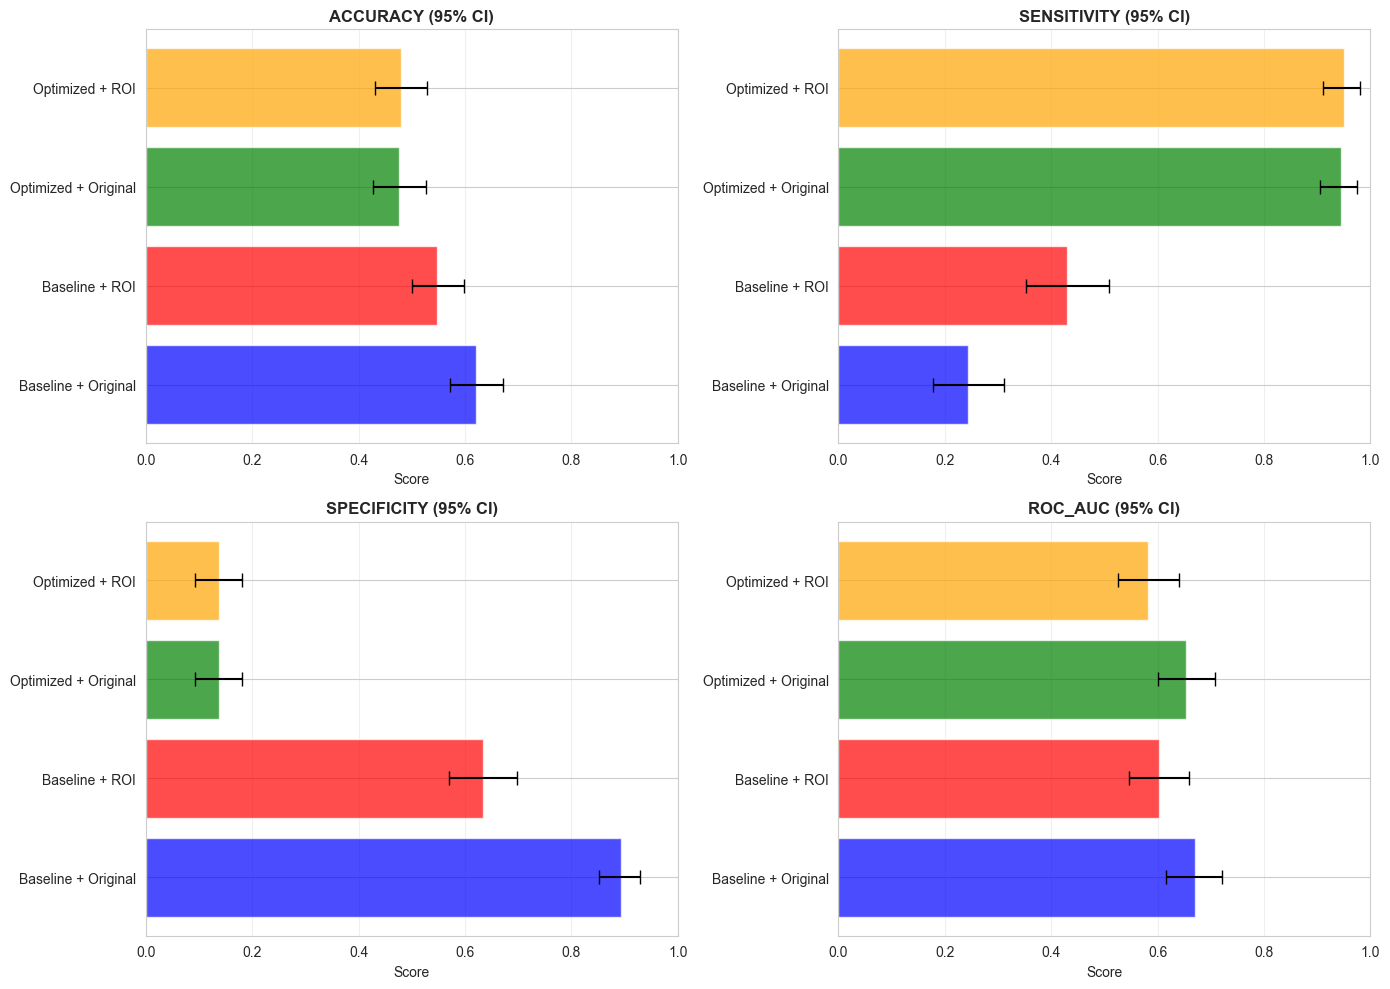

In [12]:
# Plot bootstrap distributions and CIs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors = {'Baseline + Original': 'blue', 'Baseline + ROI': 'red', 
          'Optimized + Original': 'green', 'Optimized + ROI': 'orange'}
metrics_to_plot = ['accuracy', 'sensitivity', 'specificity', 'roc_auc']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    metric_data = df_bootstrap[df_bootstrap['metric'] == metric]
    
    y_pos = np.arange(len(metric_data))
    
    for i, (_, row) in enumerate(metric_data.iterrows()):
        ax.barh(i, row['mean'], xerr=[[row['mean']-row['lower_ci']], [row['upper_ci']-row['mean']]], 
                capsize=5, color=colors[row['condition']], alpha=0.7, label=row['condition'])
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([row['condition'] for _, row in metric_data.iterrows()])
    ax.set_xlabel('Score', fontsize=10)
    ax.set_title(f'{metric.upper()} (95% CI)', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
fig_path = project_root / 'experiments/results/bootstrap_ci_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✅ Bootstrap CI plot saved to {fig_path}")
plt.show()

## Step 9: Final Summary for Paper

In [13]:
print("\n" + "="*70)
print("PHASE 3: STATISTICAL ANALYSIS COMPLETE")
print("="*70)

print("\n📊 KEY FINDINGS:")
print(f"\n1. ABLATION STUDY (Impact of ROI Preprocessing):")
print(f"   Baseline model on Original: {df_ablation.iloc[0]['accuracy']:.4f} accuracy")
print(f"   Baseline model on ROI:      {df_ablation.iloc[1]['accuracy']:.4f} accuracy")
print(f"   → Preprocessing impact:     {(df_ablation.iloc[1]['accuracy'] - df_ablation.iloc[0]['accuracy'])*100:+.2f}%")

print(f"\n2. FINE-TUNING EFFECT (Impact of Model Optimization):")
print(f"   Baseline sensitivity: {df_ablation.iloc[0]['sensitivity']:.4f}")
print(f"   Optimized sensitivity: {df_ablation.iloc[3]['sensitivity']:.4f}")
print(f"   → Improvement: {(df_ablation.iloc[3]['sensitivity'] - df_ablation.iloc[0]['sensitivity'])*100:+.2f}%")

print(f"\n3. STATISTICAL SIGNIFICANCE:")
print(f"   McNemar's test p-value: {result.pvalue:.4f}")
if result.pvalue < 0.05:
    print(f"   ✅ Changes are STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"   ⚠️  Changes are NOT statistically significant (p ≥ 0.05)")

print(f"\n4. CONFIDENCE INTERVALS (95%):")
for _, row in df_bootstrap[df_bootstrap['metric'] == 'sensitivity'].iterrows():
    print(f"   {row['condition']}: [{row['lower_ci']:.4f}, {row['upper_ci']:.4f}]")

print("\n" + "="*70)
print("✅ PHASE 3 COMPLETE - Ready for scientific paper!")
print("="*70)


PHASE 3: STATISTICAL ANALYSIS COMPLETE

📊 KEY FINDINGS:

1. ABLATION STUDY (Impact of ROI Preprocessing):
   Baseline model on Original: 0.6218 accuracy
   Baseline model on ROI:      0.5492 accuracy
   → Preprocessing impact:     -7.25%

2. FINE-TUNING EFFECT (Impact of Model Optimization):
   Baseline sensitivity: 0.2469
   Optimized sensitivity: 0.9506
   → Improvement: +70.37%

3. STATISTICAL SIGNIFICANCE:
   McNemar's test p-value: 0.0626
   ⚠️  Changes are NOT statistically significant (p ≥ 0.05)

4. CONFIDENCE INTERVALS (95%):
   Baseline + Original: [0.1781, 0.3121]
   Baseline + ROI: [0.3519, 0.5091]
   Optimized + Original: [0.9059, 0.9755]
   Optimized + ROI: [0.9107, 0.9803]

✅ PHASE 3 COMPLETE - Ready for scientific paper!
